# Reconstruction de l'environnement à l'aide d'un CNN à partir des signaux reçus

## Données

C'est un fichier .mat avec un champ "data" qui contient une matrice de 41 * 2001 signaux et un champ "map" qui contient l'état réel de la carte

Le code fait un apprentissage basique à développer plus


# 1) Imports

In [26]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import random
import copy
import os

# 2) Charger les données

In [ ]:
if not os.path.exists('data'):
    print("⚠️ Erreur : Le dossier 'data' est manquant. Consultez le README pour le télécharger.")
else:
    data = loadmat('./data/moving_ball_IA_simulations_augmented.mat')["results"]
    data = data.squeeze()

# Liste python pour faciliter l'itération
list_experiments=[]

for exp in data:
    list_experiments.append(exp)

# 3) Séparer les inputs et les outputs

On garde seulement à partir de la 1200 ème colonne les signaux pour limiter la taille et ne pas compter le trajet aller.

Pour la matrice de sortie comme c'est majoritairement des 0 on ne garde que l'espace où se trouve la demi sphère.

In [28]:
list_signals=[]
list_outputs=[]

for i in range(len(list_experiments)):
    signals, caca, output=list_experiments[i]
    list_signals.append(signals[:,1200:])
    list_outputs.append(output[15:30,:])
    
X=np.array(list_signals)

# 4) Normalisation

Il est necessaire de normaliser les données pour l'apprentissage

In [29]:
mean_val = X.mean(axis=0)
std_val = X.std(axis=0)
    
# Éviter division par zéro si std_val est très petit
std_val[std_val == 0] = 1.0

X_normalized = (X - mean_val) / std_val

# 5) Visualisation des données

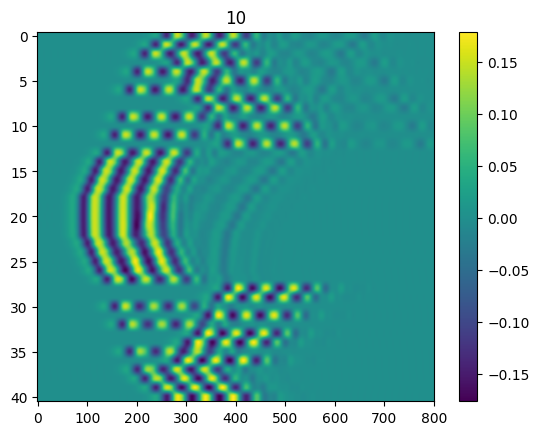

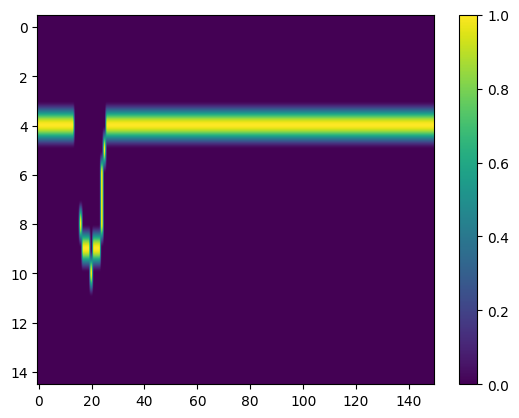

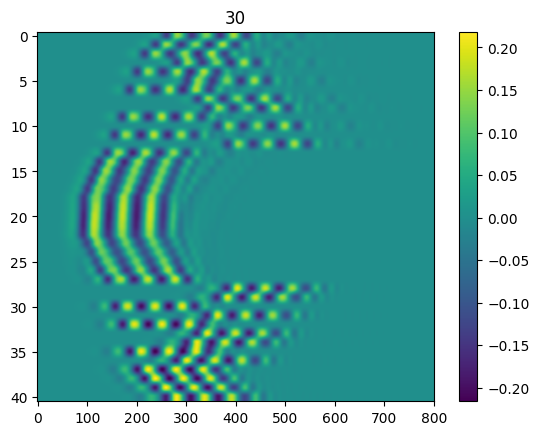

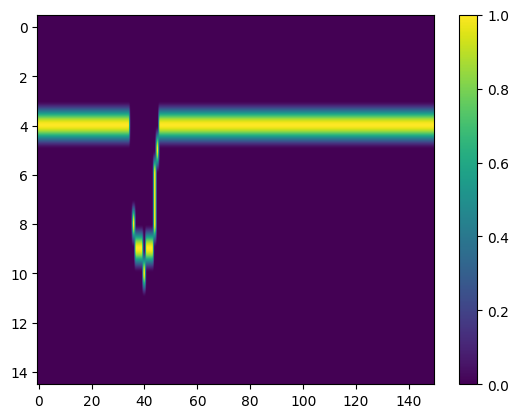

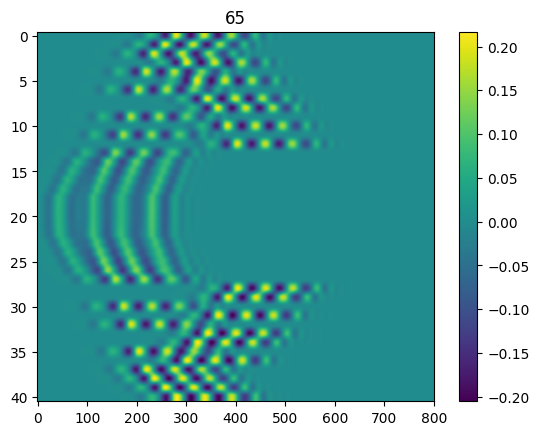

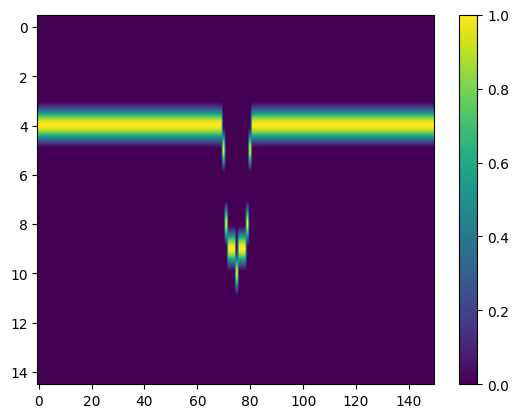

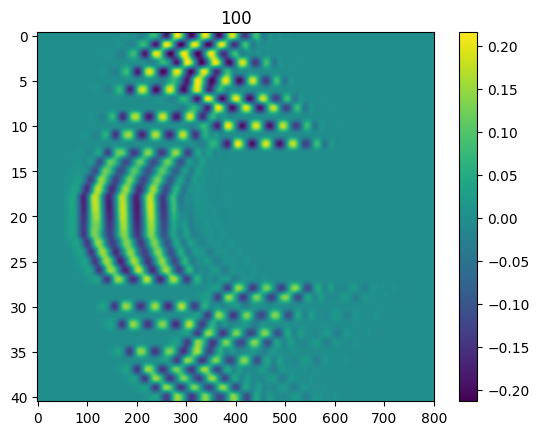

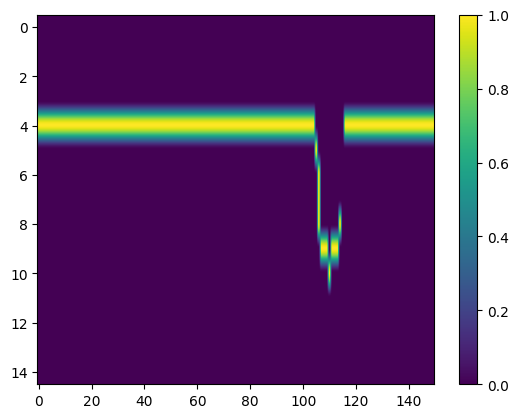

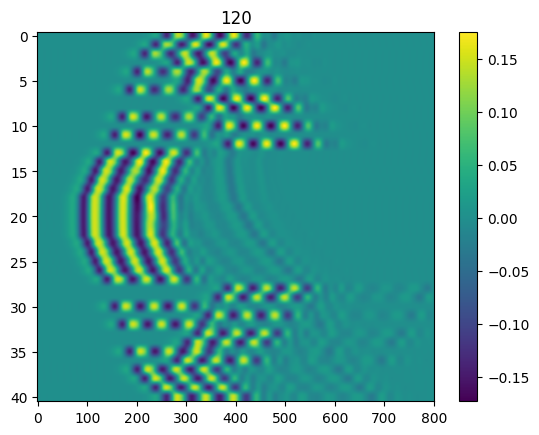

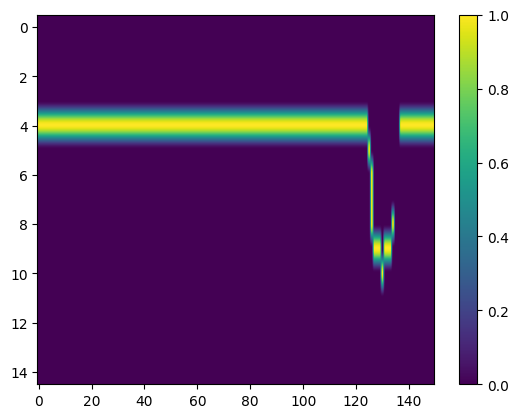

In [30]:
for example in [10,30,65,100,120]:
    plt.imshow(list_signals[example], aspect='auto')
    plt.colorbar()
    plt.title(str(example))
    plt.show()
    
    plt.imshow(list_outputs[example], aspect='auto')
    plt.colorbar()
    plt.show()

## (Optionnel) Associer les signaux pour pas qu'il y ai t de conflit avec le code de Maxime

In [31]:
X = X_normalized
y = list_outputs

# 6) Dataset personalisé

In [32]:
class SignalToImageDataset(Dataset):
    def __init__(self, X, y):
        # Conversion en tenseurs
        X = np.array(X, dtype=np.float32)  # (N, 41, 2001)
        y = np.array(y, dtype=np.float32)  # (N, 15, 150)
        
        self.X = torch.tensor(X).unsqueeze(1)  # (N, 1, 41, 2001)
        self.y = torch.tensor(y).unsqueeze(1) 
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 7) Modèle CNN

In [33]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        
        # ----- Encodeur -----
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),  # ↓

            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),  # ↓

            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2)   # ↓
        )
        
        # Taille après encodeur (calcul dynamique)
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 41, 2001)
            out = self.encoder(dummy)
            enc_h, enc_w = out.shape[2], out.shape[3]

        # ----- Décodeur -----
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 8, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.Conv2d(8, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

        # On ajuste la dernière couche pour donner exactement (15,150)
        self.output_crop = (15, 150)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        # Recadrer au cas où la taille n'est pas exacte
        h, w = self.output_crop
        x = x[:, :, :h, :w]
        return x
    
def pixel_accuracy(outputs, targets, threshold=0.5):
    """
    Calcule l'accuracy pixel par pixel.
    outputs : (N, 2250) -> probabilités
    targets : (N, 2250) -> 0 ou 1
    """
    preds = (outputs >= threshold).float()
    correct = (preds == targets).float().sum()
    total = targets.numel()
    return (correct / total).item()

def show_test_predictions(model, test_loader, device, num_samples=3, threshold=0.5):
    """
    Affiche num_samples prédictions du test set, reshaped en (15,150).
    """
    model.eval()
    shown = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            
            # Binarisation selon le seuil
            preds = (outputs >= threshold).float()
            preds=outputs

            for i in range(inputs.size(0)):
                pred_img = preds[i].view(15, 150).cpu().numpy()
                target_img = targets[i].view(15, 150).cpu().numpy()

                fig, axes = plt.subplots(1, 2, figsize=(8, 4))
                axes[0].imshow(target_img, cmap="gray")
                axes[0].set_title("Vérité terrain")
                axes[0].axis("off")

                axes[1].imshow(pred_img, cmap="gray")
                axes[1].set_title("Prédiction")
                axes[1].axis("off")

                plt.show()

                shown += 1
                if shown >= num_samples:
                    return

# 8) Fonction d'entrainement avec découpage

In [34]:
def train_and_validate(X, y, model_class, epochs=200, batch_size=8, lr=1e-3, patience=20):
    dataset = SignalToImageDataset(X, y)

    torch.manual_seed(42)
    random.seed(42)
    np.random.seed(42)

    lengths = [80, 25, 26]
    train_set, val_set, test_set = random_split(dataset, lengths)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
    
    model = model_class()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Early stopping vars
    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    
    # Pour suivi des métriques
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        train_loss_sum = 0.0
        train_acc_sum = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item()
            train_acc_sum += pixel_accuracy(outputs, targets)#.item()

        # ---- Validation ----
        model.eval()
        val_loss_sum = 0.0
        val_acc_sum = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss_sum += loss.item()
                val_acc_sum += pixel_accuracy(outputs, targets)#.item()

        train_loss = train_loss_sum / len(train_loader)
        train_acc = train_acc_sum / len(train_loader)
        val_loss = val_loss_sum / len(val_loader)
        val_acc = val_acc_sum / len(val_loader)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} "
              f"| Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} "
              f"| Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        # ---- Early stopping check ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # ---- Restore best model ----
    model.load_state_dict(best_model_wts)

    # ---- Test set evaluation ----
    model.eval()
    test_loss_sum = 0.0
    test_acc_sum = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss_sum += loss.item()
            test_acc_sum += pixel_accuracy(outputs, targets)#.item()

    test_loss = test_loss_sum / len(test_loader)
    test_acc = test_acc_sum / len(test_loader)

    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")
    
     # ---- Courbes ----
    plt.figure(figsize=(12,5))

    # Courbe Loss
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.axhline(y=test_loss, color='r', linestyle='--', label=f"Test Loss ({test_loss:.4f})")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss vs Epochs")

    # Courbe Accuracy
    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.axhline(y=test_acc, color='r', linestyle='--', label=f"Test Acc ({test_acc:.4f})")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy vs Epochs")

    plt.show()

    return model, train_loader, val_loader, test_loader

# 9) Lancement de l'entrainement

Epoch 1/200 | Train Loss: 0.6203 Acc: 0.6554 | Val Loss: 0.4316 Acc: 0.9332
Epoch 2/200 | Train Loss: 0.2836 Acc: 0.9327 | Val Loss: 0.1856 Acc: 0.9289
Epoch 3/200 | Train Loss: 0.1695 Acc: 0.9329 | Val Loss: 0.1583 Acc: 0.9346
Epoch 4/200 | Train Loss: 0.1470 Acc: 0.9455 | Val Loss: 0.1426 Acc: 0.9703
Epoch 5/200 | Train Loss: 0.1249 Acc: 0.9496 | Val Loss: 0.1130 Acc: 0.9741
Epoch 6/200 | Train Loss: 0.0995 Acc: 0.9866 | Val Loss: 0.0879 Acc: 0.9890
Epoch 7/200 | Train Loss: 0.0748 Acc: 0.9894 | Val Loss: 0.0677 Acc: 0.9895
Epoch 8/200 | Train Loss: 0.0613 Acc: 0.9897 | Val Loss: 0.0593 Acc: 0.9894
Epoch 9/200 | Train Loss: 0.0545 Acc: 0.9897 | Val Loss: 0.0534 Acc: 0.9895
Epoch 10/200 | Train Loss: 0.0504 Acc: 0.9897 | Val Loss: 0.0499 Acc: 0.9895
Epoch 11/200 | Train Loss: 0.0468 Acc: 0.9897 | Val Loss: 0.0462 Acc: 0.9895
Epoch 12/200 | Train Loss: 0.0446 Acc: 0.9897 | Val Loss: 0.0448 Acc: 0.9895
Epoch 13/200 | Train Loss: 0.0436 Acc: 0.9897 | Val Loss: 0.0437 Acc: 0.9895
Epoch 14

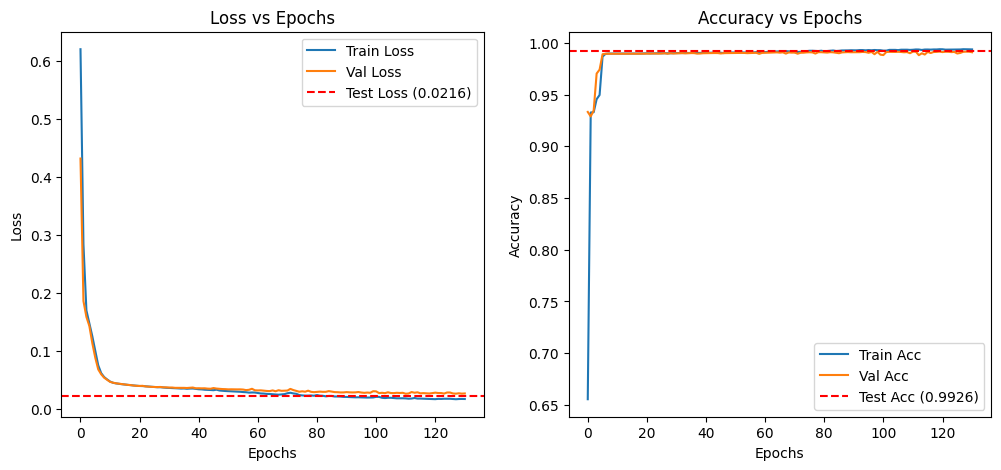

In [35]:
model, train_loader, val_loader, test_loader = train_and_validate(X, y, CNNModel)

# 10) Présentation des résultats

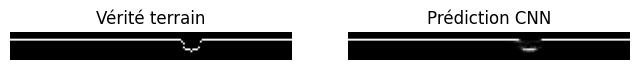

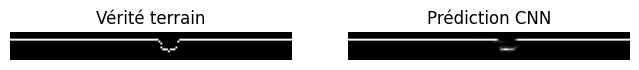

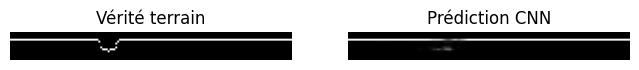

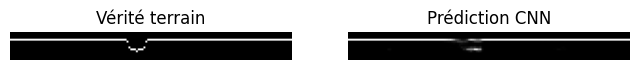

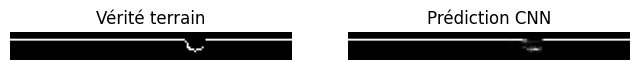

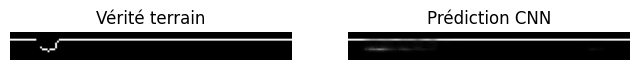

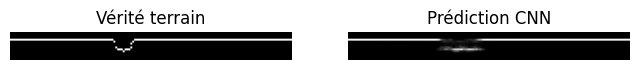

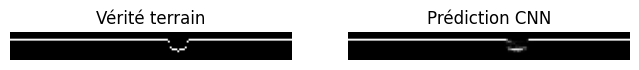

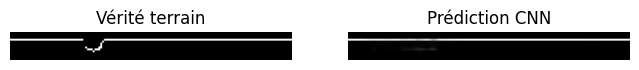

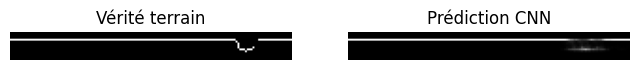

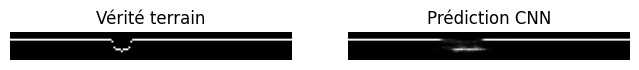

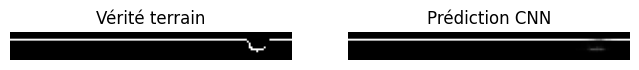

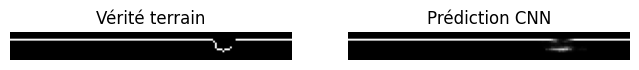

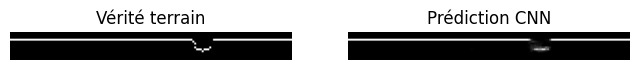

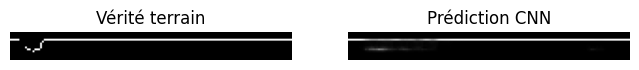

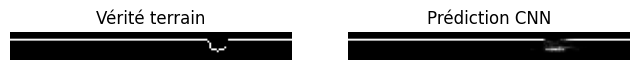

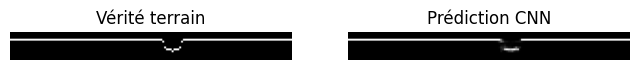

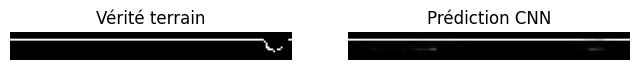

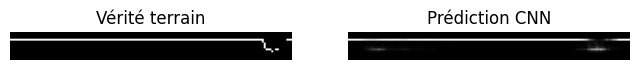

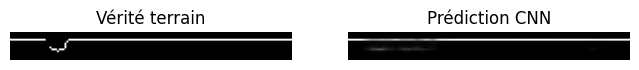

In [36]:
def show_predictions(model, loader, device, num_samples=3):
    model.eval()
    shown = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            preds = outputs.cpu().numpy()

            for i in range(inputs.size(0)):
                fig, axes = plt.subplots(1, 2, figsize=(8, 4))
                axes[0].imshow(targets[i].cpu().squeeze(), cmap="gray")
                axes[0].set_title("Vérité terrain")
                axes[0].axis("off")

                axes[1].imshow(preds[i].squeeze(), cmap="gray")
                axes[1].set_title("Prédiction CNN")
                axes[1].axis("off")
                plt.show()

                shown += 1
                if shown >= num_samples:
                    return
                
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
show_predictions(model, test_loader, device, num_samples=20)